# Import libaries

In [13]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# 0. Load data

In [6]:
path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud",
    output_dir="data"
)

DATASET_DIR = Path(path)
DATA_DIR = DATASET_DIR / "creditcard.csv"

print("Path to dataset files:", DATA_DIR)

Path to dataset files: data\creditcard.csv


# 1. Data inspection

In [11]:
df = pd.read_csv(DATA_DIR)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head)

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
<bound method NDFrame.head of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805

### Info
The dataset contains **284,807 observations and 31 features**. The main features are `Time` and `Amount`, while `V1`–`V28` contain anonymized numerical features obtained through **Principal Component Analysis (PCA)**. All features are numerical, making the dataset suitable for machine learning models.

# 2. Evaluate data analysis

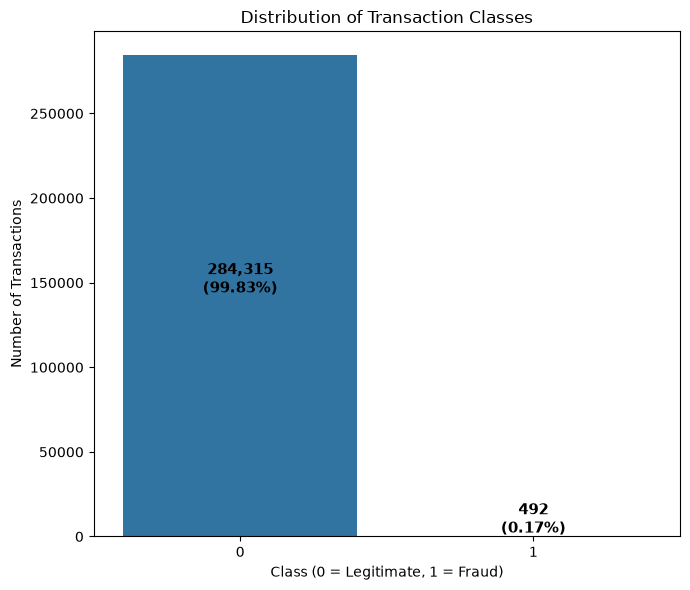

In [ ]:
counts = df["Class"].value_counts()

labels = [
    f"{count:,}\n({count / len(df) * 100:.2f}%)"
    for count in counts
]

plt.figure(figsize=(7,6))
ax = sns.countplot(data=df, x="Class")

ax.bar_label(
    ax.containers[0],
    labels=labels,
    fontsize=11,
    fontweight="bold",
    label_type="center",
    padding=12
)

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Observation
The plot clearly shows the distribution of the classes in this dataset. **Fraudut transactions account for only 0.17% of all transactions**, which is obviously a good thing in a real-world scenario. However, this creates a significant **class imbalance** problem for our machine learning model.

Because of this imbalance, we will need to take a different approach to **model selection and evaluation** compared to our previous projects. Accuracy alone will not be a reliable metric, so we will focus more on metrics such as **Precision, Recall, F1-score, and PR-AUC**.

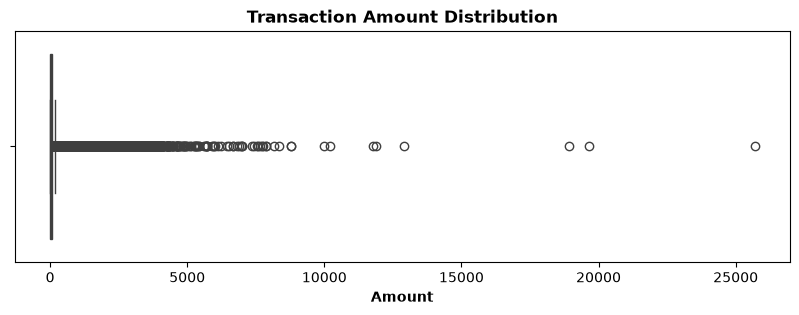

In [57]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="Amount"
)

plt.title("Transaction Amount Distribution", fontweight="bold")
plt.xlabel("Amount", fontweight="bold")

plt.show()

### Observation
The plot clearly shows that most transaction amounts are concentrated near **0**. There are also some higher-value transactions reaching around **8,000**, while only a small number of transactions exceed **10,000**. This indicates a **strong right-skewed distribution with some extreme outliers**. We will consider using a **log transformation or other scaling techniques** to handle this during preprocessing.

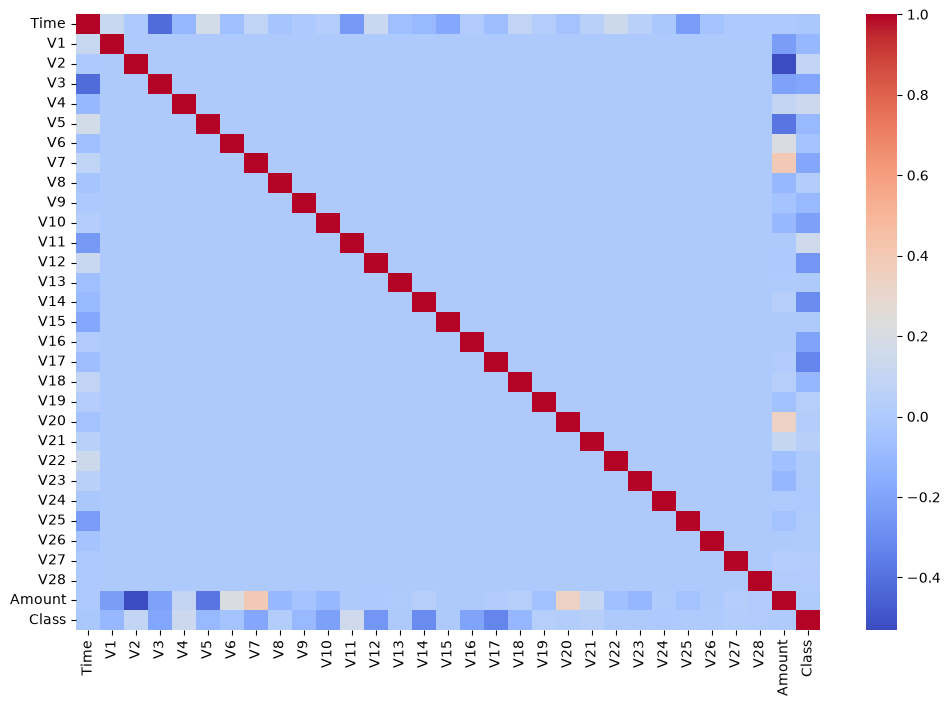

In [58]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

### Observation
The correlation matrix shows that most of the **V features have very low correlation with each other**, meaning there is no strong linear relationship between them. On the other hand, **Amount and Class** show some noticeable correlations with several features, ranging from around **-0.5 to 0.5**. This suggests that some features may contain useful information for predicting fraudulent transactions.